# MZM MoE-KAN Gate Comparison

## Overview

Three `MoEKAN` variants from `MZM_MLP.ipynb` (KAN experts, dense/soft
routing), differing only in the **gate**:

- **`kan_gate`**: a 2-layer KAN gate (`input_dim -> gating_hidden ->
  n_experts`, spline edges throughout, Eq. 2.7 in Liu et al. 2024,
  arXiv:2404.19756), `gating_hidden=24`, experts `(27,35,48,35,27)`.
- **`mlp_gate`**: the *original* MLP-based MoE's own gate, reused verbatim
  (commit `524ba0d` "Implement soft MoE": `gate_fc1` = `nnx.Linear(8, 24)` +
  ReLU, `gate_fc2` = `nnx.Linear(24, 6)`), also `gating_hidden=24`, same
  experts `(27,35,48,35,27)` as `kan_gate`.
- **`kan_gate_small`**: the *current* `MZM_MLP.ipynb` configuration — a
  KAN gate shrunk to `gating_hidden=3` so its own param count (420) closely
  matches the original MLP gate's 366 (the closest achievable integer,
  since each KAN edge already costs `grid_size+spline_order+2=10` params),
  paired with correspondingly widened experts `(31,36,42,36,31)` so the
  *model total* still lands on Base MLP5's 336,253.

`kan_gate` and `mlp_gate` isolate gate edge-type (spline vs. linear) at
**equal gate capacity** (`gating_hidden=24` both). `kan_gate_small` instead
asks a different question: with the gate itself param-matched to the
original MLP gate (not just width-matched), does a spline gate still lose
anything relative to `mlp_gate`, or does shrinking it to a comparable
budget change the picture set up by `kan_gate`?

**Parameter count** (formula per `MZM_MLP.ipynb`'s KAN/MoE-KAN markdown —
`params(KANLinear) = n_in*n_out*(grid_size+spline_order+2)`, `=10` per edge
here; MLP gate edges cost 1 weight + (for the output-side node) 1 bias):

| | experts | gate | total |
|---|---|---|---|
| `kan_gate` | 332,820 | 3,360 | **336,180** |
| `mlp_gate` | 332,820 | 366 | **333,186** |
| `kan_gate_small` | 335,820 | 420 | **336,240** |

`kan_gate` vs `mlp_gate` differ by ~0.9% (2,994 params) — the direct,
unavoidable cost of a spline gate at equal hidden width. `kan_gate_small`
sits almost exactly on Base's 336,253 (−0.004%) and on `mlp_gate`'s own
gate-param budget (420 vs. 366), at the cost of a much narrower gate
(`gating_hidden=3` vs. 24) and wider experts.

## Setup

In [13]:
# ==============================
# Import Required Libraries
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import re

from tqdm.auto import tqdm

import jax
import jax.numpy as jnp
import optax
from flax import nnx

# Reproducibility
random_state = 123
np.random.seed(random_state)

## Model Definitions

In [14]:
class KANLinear(nnx.Module):
    """A single KAN layer: an n_in x n_out matrix of learnable 1D edge
    functions phi(x) = w_b * silu(x) + w_s * spline(x), replacing an MLP
    layer's linear weight matrix + fixed nonlinearity (Liu et al. 2024,
    "KAN: Kolmogorov-Arnold Networks", arXiv:2404.19756, Eq. 2.5/2.10-2.12).
    spline(x) is a linear combination of order-`spline_order` B-spline basis
    functions over a fixed, static grid spanning `grid_range` — no dynamic
    grid update or grid extension (official-pykan refinements, out of scope
    here): the base branch's silu(x) is evaluated on the *unclipped* input
    and so handles extrapolation beyond the grid, per the paper's own
    residual-activation design."""

    def __init__(
        self, in_features, out_features, grid_size=5, spline_order=3,
        grid_range=(-2.0, 2.0), *, rngs: nnx.Rngs,
    ):
        self.in_features = in_features
        self.out_features = out_features
        self.grid_size = grid_size
        self.spline_order = spline_order
        self.grid_range = grid_range

        h = (grid_range[1] - grid_range[0]) / grid_size
        grid = np.arange(-spline_order, grid_size + spline_order + 1) * h + grid_range[0]
        # Static (non-trainable) knot vector: a plain Python tuple, not an
        # array/nnx.Variable attribute, so it stays out of nnx.split's
        # (Param, BatchStat) partition — same pattern as other static
        # int/tuple config attributes (e.g. MLP5's hidden_dims) elsewhere
        # in this notebook.
        self.knots = tuple(float(v) for v in grid)

        he = jax.nn.initializers.he_uniform()
        num_basis = grid_size + spline_order
        self.base_weight = nnx.Param(he(rngs.params(), (out_features, in_features)))
        self.spline_scaler = nnx.Param(jnp.ones((out_features, in_features)))
        self.spline_weight = nnx.Param(
            jax.random.normal(rngs.params(), (out_features, in_features, num_basis)) * 0.1
        )

    def _b_splines(self, x):
        """x: (..., in_features) -> (..., in_features, grid_size + spline_order)"""
        knots = jnp.asarray(self.knots, dtype=x.dtype)
        xc = jnp.clip(x, self.grid_range[0], self.grid_range[1])[..., None]
        bases = ((xc >= knots[:-1]) & (xc < knots[1:])).astype(x.dtype)
        for order in range(1, self.spline_order + 1):
            left = (xc - knots[: -order - 1]) / (knots[order:-1] - knots[: -order - 1])
            right = (knots[order + 1 :] - xc) / (knots[order + 1 :] - knots[1:-order])
            bases = left * bases[..., :-1] + right * bases[..., 1:]
        return bases

    def __call__(self, x, *, train: bool = False, rngs=None):
        base_out = jax.nn.silu(x) @ self.base_weight[...].T
        bases = self._b_splines(x)  # (..., in_features, num_basis)
        weighted = self.spline_weight[...] * self.spline_scaler[...][..., None]
        spline_out = jnp.einsum("oik,...ik->...o", weighted, bases)
        return base_out + spline_out, {}


class KAN(nnx.Module):
    """Stack of KANLinear layers: KAN(x) = (Phi_{L-1} o ... o Phi_0)(x)
    (Eq. 2.7). `hidden_dims` mirrors MLP5's own 5-tuple API so it plugs into
    the same ARCHS/run_config/scale-matching scaffold unchanged; grid_size
    and spline_order are shared across all layers. No BatchNorm/dropout
    equivalent — the paper doesn't use one and none is needed; weight_decay
    in adamw already regularizes every nnx.Param uniformly."""

    def __init__(
        self, input_dim=8, output_dim=3, hidden_dims=(63, 95, 111, 95, 63),
        grid_size=5, spline_order=3, *, rngs: nnx.Rngs,
    ):
        dims = (input_dim, *hidden_dims, output_dim)
        self.layers = nnx.data([
            KANLinear(d_in, d_out, grid_size=grid_size, spline_order=spline_order, rngs=rngs)
            for d_in, d_out in zip(dims[:-1], dims[1:])
        ])

    def __call__(self, x, *, train: bool = False, rngs=None):
        for layer in self.layers:
            x, _ = layer(x, train=train, rngs=rngs)
        return x, {}

In [15]:
class MoEKAN(nnx.Module):
    """Mixture-of-Experts with KAN experts and a selectable gate type:

    - `gate_type="kan"`: a 2-layer KAN gate (input_dim -> gating_hidden ->
      n_experts, spline edges throughout, Eq. 2.7).
    - `gate_type="mlp"`: the original MLP-based MoE's own gate structure
      (commit 524ba0d "Implement soft MoE": nnx.Linear(input_dim,
      gating_hidden) + ReLU + nnx.Linear(gating_hidden, n_experts)), reused
      verbatim so the *only* difference between the two gate_type variants
      is the gate's edge type (spline vs. linear weight); every other
      hyperparameter, including gating_hidden itself, is held identical.

    Experts are always KAN (`KAN` above) regardless of gate_type — dense
    (soft) routing, all n_experts always active, softmax-weighted sum
    (mirrors MZM_MLP.ipynb's own MoEKAN, just with the gate type as a free
    knob instead of hardcoded to "kan")."""

    def __init__(
        self, input_dim=8, output_dim=3, n_experts=6,
        expert_hidden_dims=(27, 35, 48, 35, 27), gating_hidden=24,
        gate_type="kan", grid_size=5, spline_order=3, *, rngs: nnx.Rngs,
    ):
        assert gate_type in ("kan", "mlp")
        self.gate_type = gate_type

        # NOTE: must wrap in nnx.data(...) — a plain list here raises
        # ValueError on this flax version ("Found data ... assigned to
        # static attribute").
        self.experts = nnx.data([
            KAN(input_dim=input_dim, output_dim=output_dim,
                hidden_dims=expert_hidden_dims, grid_size=grid_size,
                spline_order=spline_order, rngs=rngs)
            for _ in range(n_experts)
        ])

        if gate_type == "kan":
            self.gate = KAN(
                input_dim=input_dim, output_dim=n_experts,
                hidden_dims=(gating_hidden,), grid_size=grid_size,
                spline_order=spline_order, rngs=rngs,
            )
        else:
            he = jax.nn.initializers.he_uniform()
            zeros = jax.nn.initializers.zeros
            self.gate_fc1 = nnx.Linear(input_dim, gating_hidden,
                                        kernel_init=he, bias_init=zeros, rngs=rngs)
            self.gate_fc2 = nnx.Linear(gating_hidden, n_experts,
                                        kernel_init=he, bias_init=zeros, rngs=rngs)

    def _gate_logits(self, x, *, train, rngs):
        if self.gate_type == "kan":
            logits, _ = self.gate(x, train=train, rngs=rngs)
            return logits
        h = nnx.relu(self.gate_fc1(x))
        return self.gate_fc2(h)

    def __call__(self, x, *, train: bool = False, rngs=None):
        expert_outs = jnp.stack(
            [expert(x, train=train, rngs=rngs)[0] for expert in self.experts],
            axis=-1,
        )  # (batch, output_dim, n_experts)
        gate_weights = jax.nn.softmax(
            self._gate_logits(x, train=train, rngs=rngs), axis=-1
        )  # (batch, n_experts)
        pred = jnp.einsum("boe,be->bo", expert_outs, gate_weights)
        return pred, {}

## Data Loading & Preprocessing

In [16]:
# ==============================
# Load and Preprocess Data
# ==============================
# from google.colab import drive
# drive.mount('/content/drive')
# file_path = "/content/drive/MyDrive/MZM Data/Sim_generated_dataset.txt"
file_path = "Sim_generated_dataset.txt"

In [17]:
with open(file_path) as f:
    cleaned = [re.sub(r'[\[\]]', '', line.strip()) for line in f]

df = pd.read_csv(StringIO("\n".join(cleaned)), header=None)
df.columns = [
    "PN_offset", "Bias_V", "Core_width", "P+_width", "N+_width",
    "P_width", "N_width", "Phase_length", "BW_3dB", "IL", "V_pi"
]

# Data cleaning: remove rows with extreme V_pi (>500, <0)
df_cleaned = df[(df['V_pi'] < 500) & (df['V_pi'] > 0)].copy()
print(f"Dataset size after cleaning: {len(df_cleaned)} samples")

# Split features / targets
feature_cols = df_cleaned.columns[:8]
target_cols = df_cleaned.columns[8:]

x = df_cleaned[feature_cols].values
y = df_cleaned[target_cols].values

# Train / test split
x_train_raw, x_test_raw, y_train_raw, y_test_raw = train_test_split(
    x, y, test_size=0.1, random_state=random_state
)

# ==============================
# Scaling (fit on TRAIN only)
# ==============================
scaler_x = MinMaxScaler()  # Features
scaler_y1 = StandardScaler()  # BW_3dB
scaler_y2 = StandardScaler()  # IL
scaler_y3 = StandardScaler()  # V_pi

x_train_scaled = scaler_x.fit_transform(x_train_raw)
y_train_scaled = np.hstack([
    scaler_y1.fit_transform(y_train_raw[:, 0:1]),
    scaler_y2.fit_transform(y_train_raw[:, 1:2]),
    scaler_y3.fit_transform(y_train_raw[:, 2:3]),
])

x_test_scaled = scaler_x.transform(x_test_raw)
y_test_scaled = np.hstack([
    scaler_y1.transform(y_test_raw[:, 0:1]),
    scaler_y2.transform(y_test_raw[:, 1:2]),
    scaler_y3.transform(y_test_raw[:, 2:3]),
])

# Convert to tensors
x_train_t = jnp.asarray(x_train_scaled, dtype=jnp.float32)
y_train_t = jnp.asarray(y_train_scaled, dtype=jnp.float32)
x_test_t  = jnp.asarray(x_test_scaled, dtype=jnp.float32)
y_test_t  = jnp.asarray(y_test_scaled, dtype=jnp.float32)

print(f"Train: {x_train_t.shape[0]} | Test: {x_test_t.shape[0]}")
df_cleaned.describe()

Dataset size after cleaning: 9614 samples
Train: 8652 | Test: 962


,PN_offset,Bias_V,Core_width,P+_width,N+_width,P_width,N_width,Phase_length,BW_3dB,IL,V_pi
count,9.614000e+03,9614.000000,9.614000e+03,9.614000e+03,9.614000e+03,9.614000e+03,9.614000e+03,9614.000000,9614.000000,9614.000000,9614.000000
mean,-4.106982e-09,-5.965076,4.774007e-07,2.584718e-07,2.618829e-07,7.853203e-07,7.904345e-07,0.002285,46.011836,1.577726,33.900601
std,1.272187e-07,2.251585,2.488443e-08,1.315607e-07,1.370419e-07,1.293550e-07,1.313482e-07,0.001030,13.757979,0.896971,31.995194
min,-2.150000e-07,-10.000000,4.050720e-07,4.509540e-08,4.500550e-08,4.510390e-07,4.501570e-07,0.000500,2.256410,0.166187,3.564810
25%,-1.064180e-07,-7.874185,4.613922e-07,1.472730e-07,1.420500e-07,6.774380e-07,6.796328e-07,0.001415,34.923077,0.881409,14.321325
50%,0.000000e+00,-5.819890,4.754365e-07,2.522630e-07,2.602395e-07,7.865730e-07,7.942275e-07,0.002229,44.974359,1.394790,23.757300
75%,9.655928e-08,-4.041150,4.891833e-07,3.689188e-07,3.806483e-07,8.958177e-07,9.036680e-07,0.003167,54.800000,2.162227,41.027525
max,2.150000e-07,-2.250820,6.000000e-07,4.998190e-07,5.000000e-07,1.098400e-06,1.099670e-06,0.005971,74.000000,5.255890,394.839000


## GPU Setup

In [18]:
print(f"JAX devices: {jax.devices()}")
print(f"Using backend: {jax.default_backend()}")
print(f"x_train_t device: {x_train_t.device}")

JAX devices: [CudaDevice(id=0)]
Using backend: gpu
x_train_t device: cuda:0


## Training Function

In [19]:
def train_model(
    model_ctor,  # Callable[[nnx.Rngs], nnx.Module] — builds the model to train
    batch_size=16,
    learning_rate=1e-3,
    weight_decay=0.05,
    betas=(0.9, 0.999),
    n_epoch=100,
    verbose=False,
    trial=None,  # Optuna trial for pruning
    early_stopping_patience=20,
    early_stopping_min_delta=1e-5,
    restore_best_weights=True,
    seed=random_state,
    x_train=None,
    y_train=None,
):
    """
    Build, train and evaluate a model with the given hyperparameters.

    `model_ctor(rngs) -> nnx.Module` builds the model; any architecture is
    supported as long as `model.__call__(x, *, train, rngs=None)` returns
    `(pred, new_stats)`, where `new_stats` is a plain nested dict/int-keyed
    structure whose shape matches `nnx.to_pure_dict(nnx.state(model,
    nnx.BatchStat))` — see MLP5/KAN below for two conforming examples.

    x_train/y_train default to the module-level x_train_t/y_train_t but can be
    overridden (e.g. bootstrap-resampled or subsampled) for the comparison
    studies below; the held-out test set is always x_test_t/y_test_t.

    Each epoch's batches run as a single `jax.lax.scan` under one `jit` call
    instead of a Python loop dispatching one XLA call per batch, and per-split
    evaluation is a single whole-array forward pass instead of a batched loop
    — both avoid host/device round-trips that dominate runtime at this model
    size. Scanning over fixed-size batches means each epoch drops the last
    partial batch (equivalent to `drop_last=True`), which discards at most
    `batch_size - 1` samples per epoch.

    Returns
    -------
    dict with keys:
        'train_loss', 'test_loss',
        'train_history', 'test_history',
        'model_state'
    """
    x_train_data = x_train_t if x_train is None else x_train
    y_train_data = y_train_t if y_train is None else y_train

    # --- Build model ---
    init_key, epoch_key = jax.random.split(jax.random.PRNGKey(seed))
    model = model_ctor(nnx.Rngs(init_key))
    graphdef, params, batch_stats = nnx.split(model, nnx.Param, nnx.BatchStat)

    n_params = sum(p.size for p in jax.tree_util.tree_leaves(params))

    tx = optax.adamw(
        learning_rate, weight_decay=weight_decay, b1=betas[0], b2=betas[1],
    )
    opt_state = tx.init(params)

    def apply_fn(params, batch_stats, x, dropout_key, train):
        m = nnx.merge(graphdef, params, batch_stats)
        dropout_rngs = nnx.Rngs(dropout=dropout_key) if train else None
        pred, new_stats = m(x, train=train, rngs=dropout_rngs)
        if not train:
            return pred, batch_stats
        new_batch_stats = jax.tree_util.tree_map(lambda a: a, batch_stats)
        old_pure = nnx.to_pure_dict(batch_stats)
        blended_pure = jax.tree_util.tree_map(
            lambda old, new: BN_MOMENTUM * old + (1 - BN_MOMENTUM) * new,
            old_pure, new_stats,
        )
        nnx.replace_by_pure_dict(new_batch_stats, blended_pure)
        return pred, new_batch_stats

    def loss_fn(params, batch_stats, x_batch, y_batch, dropout_key):
        pred, new_batch_stats = apply_fn(params, batch_stats, x_batch, dropout_key, True)
        loss = jnp.mean((pred - y_batch) ** 2)
        return loss, new_batch_stats

    def train_step(params, batch_stats, opt_state, x_batch, y_batch, dropout_key):
        (loss, new_batch_stats), grads = jax.value_and_grad(loss_fn, has_aux=True)(
            params, batch_stats, x_batch, y_batch, dropout_key
        )
        updates, opt_state = tx.update(grads, opt_state, params)
        params = optax.apply_updates(params, updates)
        return params, new_batch_stats, opt_state

    n_train = x_train_data.shape[0]
    n_batches = max(n_train // batch_size, 1)

    @jax.jit
    def run_epoch(params, batch_stats, opt_state, perm, drop_key):
        """One full epoch of training as a single scan (one XLA dispatch),
        instead of a Python loop issuing one dispatch per batch."""
        batch_idx = perm[: n_batches * batch_size].reshape(n_batches, batch_size)
        batch_keys = jax.random.split(drop_key, n_batches)

        def step(carry, xs):
            params, batch_stats, opt_state = carry
            idx, key = xs
            x_batch = x_train_data[idx]
            y_batch = y_train_data[idx]
            params, batch_stats, opt_state = train_step(
                params, batch_stats, opt_state, x_batch, y_batch, key
            )
            return (params, batch_stats, opt_state), None

        (params, batch_stats, opt_state), _ = jax.lax.scan(
            step, (params, batch_stats, opt_state), (batch_idx, batch_keys)
        )
        return params, batch_stats, opt_state

    @jax.jit
    def eval_loss(params, batch_stats, x, y):
        pred, _ = apply_fn(params, batch_stats, x, None, False)
        return jnp.mean((pred - y) ** 2)

    train_hist = np.zeros(n_epoch)
    test_hist  = np.zeros(n_epoch)

    # --- Early stopping bookkeeping ---
    best_test_loss = float('inf')
    best_epoch = -1
    epochs_without_improvement = 0
    best_state = None
    stopped_epoch = n_epoch - 1

    # --- Training loop ---
    epoch_iter = tqdm(
        range(n_epoch),
        desc="Training",
        dynamic_ncols=True,
        leave=False,
        colour="cyan",
        disable=not verbose,
    )

    for epoch in epoch_iter:
        epoch_key, perm_key, drop_key = jax.random.split(epoch_key, 3)
        perm = jax.random.permutation(perm_key, n_train)
        params, batch_stats, opt_state = run_epoch(params, batch_stats, opt_state, perm, drop_key)

        # --- Evaluation ---
        train_loss = float(eval_loss(params, batch_stats, x_train_data, y_train_data))
        test_loss = float(eval_loss(params, batch_stats, x_test_t, y_test_t))
        train_hist[epoch] = train_loss
        test_hist[epoch] = test_loss

        if verbose:
            epoch_iter.set_postfix({
                "train": f"{train_loss:.4e}",
                "test": f"{test_loss:.4e}",
                "best": f"{best_test_loss:.4e}" if np.isfinite(best_test_loss) else "inf",
            })

        # Optuna pruning
        if trial is not None:
            trial.report(test_loss, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

        # Early stopping (based on test loss)
        if test_loss < (best_test_loss - early_stopping_min_delta):
            best_test_loss = test_loss
            best_epoch = epoch
            epochs_without_improvement = 0
            if restore_best_weights:
                best_state = (params, batch_stats)
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= early_stopping_patience:
            stopped_epoch = epoch
            if verbose:
                print(
                    f"Early stopping at epoch {epoch} (best epoch: {best_epoch}, best test: {best_test_loss:.6f})"
                )
            break

    # Keep only executed part of histories
    executed_epochs = stopped_epoch + 1
    train_hist = train_hist[:executed_epochs]
    test_hist = test_hist[:executed_epochs]

    # Restore best weights if requested and available
    if restore_best_weights and best_state is not None:
        params, batch_stats = best_state

    # Re-evaluate final model (restored best if enabled)
    final_train_loss = float(eval_loss(params, batch_stats, x_train_data, y_train_data))
    final_test_loss = float(eval_loss(params, batch_stats, x_test_t, y_test_t))

    return {
        'train_loss': final_train_loss,
        'test_loss':  final_test_loss,
        'best_test_loss': best_test_loss,
        'best_epoch': best_epoch,
        'stopped_epoch': stopped_epoch,
        'train_history': train_hist,
        'test_history':  test_hist,
        'model_state': (graphdef, params, batch_stats),
        'n_params': n_params,
    }

## Training All Three Variants

In [20]:
kan_gate_train = train_model(
    model_ctor=lambda rngs: MoEKAN(input_dim=8, output_dim=3, n_experts=6,
                                    expert_hidden_dims=(27, 35, 48, 35, 27),
                                    gating_hidden=24, gate_type="kan",
                                    grid_size=5, spline_order=3, rngs=rngs),
    verbose=True,
)

print(f"KAN-gate train loss: {kan_gate_train['train_loss']:.6f}")
print(f"KAN-gate test loss: {kan_gate_train['test_loss']:.6f}")

Training:   0%|          | 0/100 [00:00<?, ?it/s]

Early stopping at epoch 75 (best epoch: 55, best test: 0.006729)
KAN-gate train loss: 0.014109
KAN-gate test loss: 0.006729


In [21]:
mlp_gate_train = train_model(
    model_ctor=lambda rngs: MoEKAN(input_dim=8, output_dim=3, n_experts=6,
                                    expert_hidden_dims=(27, 35, 48, 35, 27),
                                    gating_hidden=24, gate_type="mlp",
                                    grid_size=5, spline_order=3, rngs=rngs),
    verbose=True,
)

print(f"MLP-gate train loss: {mlp_gate_train['train_loss']:.6f}")
print(f"MLP-gate test loss: {mlp_gate_train['test_loss']:.6f}")

Training:   0%|          | 0/100 [00:00<?, ?it/s]

Early stopping at epoch 61 (best epoch: 41, best test: 0.006749)
MLP-gate train loss: 0.014005
MLP-gate test loss: 0.006749


In [22]:
kan_gate_small_train = train_model(
    model_ctor=lambda rngs: MoEKAN(input_dim=8, output_dim=3, n_experts=6,
                                    expert_hidden_dims=(31, 36, 42, 36, 31),
                                    gating_hidden=3, gate_type="kan",
                                    grid_size=5, spline_order=3, rngs=rngs),
    verbose=True,
)

print(f"KAN-gate (small) train loss: {kan_gate_small_train['train_loss']:.6f}")
print(f"KAN-gate (small) test loss: {kan_gate_small_train['test_loss']:.6f}")

Training:   0%|          | 0/100 [00:00<?, ?it/s]

Early stopping at epoch 61 (best epoch: 41, best test: 0.006875)
KAN-gate (small) train loss: 0.014147
KAN-gate (small) test loss: 0.006875


## Results

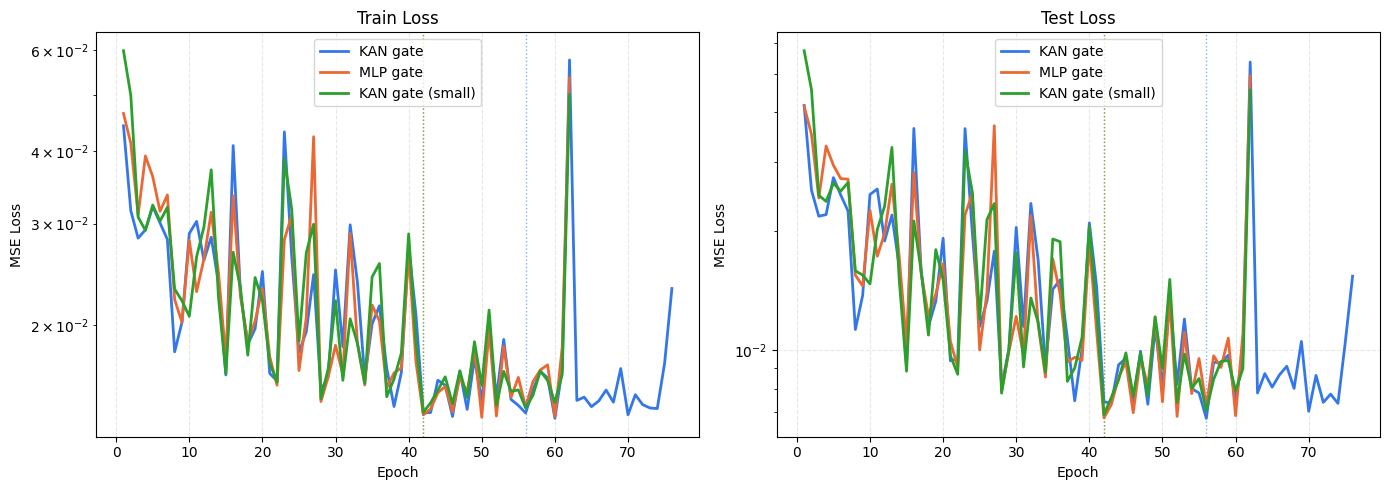

In [23]:
color_kan_gate = "#3477eb"
color_mlp_gate = "#eb6834"
color_kan_gate_small = "#2ca02c"

epochs_kan_gate = np.arange(1, len(kan_gate_train["train_history"]) + 1)
epochs_mlp_gate = np.arange(1, len(mlp_gate_train["train_history"]) + 1)
epochs_kan_gate_small = np.arange(1, len(kan_gate_small_train["train_history"]) + 1)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(epochs_kan_gate, kan_gate_train["train_history"], color=color_kan_gate, lw=2, label="KAN gate")
axs[0].plot(epochs_mlp_gate, mlp_gate_train["train_history"], color=color_mlp_gate, lw=2, label="MLP gate")
axs[0].plot(epochs_kan_gate_small, kan_gate_small_train["train_history"], color=color_kan_gate_small, lw=2, label="KAN gate (small)")
axs[0].axvline(kan_gate_train["best_epoch"] + 1, color=color_kan_gate, lw=1, linestyle=":", alpha=0.6)
axs[0].axvline(mlp_gate_train["best_epoch"] + 1, color=color_mlp_gate, lw=1, linestyle=":", alpha=0.6)
axs[0].axvline(kan_gate_small_train["best_epoch"] + 1, color=color_kan_gate_small, lw=1, linestyle=":", alpha=0.6)
axs[0].set_yscale("log")
axs[0].set_title("Train Loss")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("MSE Loss")
axs[0].grid(True, linestyle="--", alpha=0.3)
axs[0].legend()

axs[1].plot(epochs_kan_gate, kan_gate_train["test_history"], color=color_kan_gate, lw=2, label="KAN gate")
axs[1].plot(epochs_mlp_gate, mlp_gate_train["test_history"], color=color_mlp_gate, lw=2, label="MLP gate")
axs[1].plot(epochs_kan_gate_small, kan_gate_small_train["test_history"], color=color_kan_gate_small, lw=2, label="KAN gate (small)")
axs[1].axvline(kan_gate_train["best_epoch"] + 1, color=color_kan_gate, lw=1, linestyle=":", alpha=0.6)
axs[1].axvline(mlp_gate_train["best_epoch"] + 1, color=color_mlp_gate, lw=1, linestyle=":", alpha=0.6)
axs[1].axvline(kan_gate_small_train["best_epoch"] + 1, color=color_kan_gate_small, lw=1, linestyle=":", alpha=0.6)
axs[1].set_yscale("log")
axs[1].set_title("Test Loss")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("MSE Loss")
axs[1].grid(True, linestyle="--", alpha=0.3)
axs[1].legend()

plt.tight_layout()
plt.show()

In [24]:
print(f"{'variant':10s} {'n_params':>10s} {'train_loss':>12s} {'test_loss':>12s}")
for name, r in [("kan_gate", kan_gate_train), ("mlp_gate", mlp_gate_train), ("kan_gate_small", kan_gate_small_train)]:
    print(f"{name:10s} {r['n_params']:>10d} {r['train_loss']:>12.6f} {r['test_loss']:>12.6f}")

variant      n_params   train_loss    test_loss
kan_gate       336180     0.014109     0.006729
mlp_gate       333186     0.014005     0.006749
kan_gate_small     336240     0.014147     0.006875


## Variance Comparison (Bootstrap)

Retrain each gate variant 15 times on bootstrap resamples of the training
set (same size, sampled with replacement) with a different seed each time,
to compare test-loss distributions rather than a single point estimate —
the same methodology `MZM_MLP.ipynb` uses for its own architecture
comparisons.

In [25]:
GATE_CTORS = {
    "kan_gate": lambda rngs: MoEKAN(input_dim=8, output_dim=3, n_experts=6,
                                     expert_hidden_dims=(27, 35, 48, 35, 27),
                                     gating_hidden=24, gate_type="kan",
                                     grid_size=5, spline_order=3, rngs=rngs),
    "mlp_gate": lambda rngs: MoEKAN(input_dim=8, output_dim=3, n_experts=6,
                                     expert_hidden_dims=(27, 35, 48, 35, 27),
                                     gating_hidden=24, gate_type="mlp",
                                     grid_size=5, spline_order=3, rngs=rngs),
    "kan_gate_small": lambda rngs: MoEKAN(input_dim=8, output_dim=3, n_experts=6,
                                           expert_hidden_dims=(31, 36, 42, 36, 31),
                                           gating_hidden=3, gate_type="kan",
                                           grid_size=5, spline_order=3, rngs=rngs),
}

n_full = x_train_t.shape[0]
n_bootstrap = 15

variance_results = {"kan_gate": [], "mlp_gate": [], "kan_gate_small": []}
for i in tqdm(range(n_bootstrap), desc="Bootstrap"):
    seed = 1000 + i
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, n_full, size=n_full)
    x_tr, y_tr = x_train_t[idx], y_train_t[idx]
    for name, ctor in GATE_CTORS.items():
        r = train_model(
            model_ctor=ctor, n_epoch=60, early_stopping_patience=15,
            seed=seed, x_train=x_tr, y_train=y_tr,
        )
        variance_results[name].append({
            "seed": seed, "test_loss": r["test_loss"], "train_loss": r["train_loss"],
        })

for name in ["kan_gate", "mlp_gate", "kan_gate_small"]:
    losses = np.array([row["test_loss"] for row in variance_results[name]])
    print(f"{name}: test_loss mean={losses.mean():.5f} std={losses.std():.5f} (n={len(losses)})")

Bootstrap:   0%|          | 0/15 [00:00<?, ?it/s]

kan_gate: test_loss mean=0.00727 std=0.00062 (n=15)
mlp_gate: test_loss mean=0.00740 std=0.00057 (n=15)
kan_gate_small: test_loss mean=0.00771 std=0.00077 (n=15)


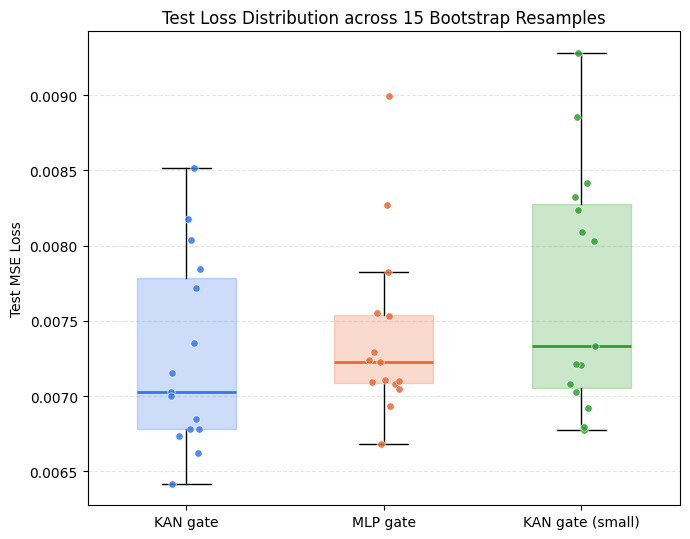

In [26]:
fig, ax = plt.subplots(figsize=(7, 5.5))

data_box = [
    [row["test_loss"] for row in variance_results["kan_gate"]],
    [row["test_loss"] for row in variance_results["mlp_gate"]],
    [row["test_loss"] for row in variance_results["kan_gate_small"]],
]
colors = [color_kan_gate, color_mlp_gate, color_kan_gate_small]
bp = ax.boxplot(data_box, positions=[0, 1, 2], widths=0.5, patch_artist=True, showfliers=False)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.25)
    patch.set_edgecolor(color)
for median, color in zip(bp["medians"], colors):
    median.set_color(color)
    median.set_linewidth(2)

rng_jitter = np.random.default_rng(0)
for pos, name, color in [(0, "kan_gate", color_kan_gate), (1, "mlp_gate", color_mlp_gate), (2, "kan_gate_small", color_kan_gate_small)]:
    ys = [row["test_loss"] for row in variance_results[name]]
    xs = pos + rng_jitter.uniform(-0.08, 0.08, size=len(ys))
    ax.scatter(xs, ys, color=color, s=28, alpha=0.85, edgecolors="white", linewidth=0.5, zorder=3)

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["KAN gate", "MLP gate", "KAN gate (small)"])
ax.set_ylabel("Test MSE Loss")
ax.set_title(f"Test Loss Distribution across {n_bootstrap} Bootstrap Resamples")
ax.grid(True, linestyle="--", alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## Summary

In [ ]:
print("Canonical run (single training, 100 epochs / patience 20):")
for name, r in [("kan_gate", kan_gate_train), ("mlp_gate", mlp_gate_train), ("kan_gate_small", kan_gate_small_train)]:
    print(f"  {name}: n_params={r['n_params']}, train_loss={r['train_loss']:.6f}, test_loss={r['test_loss']:.6f}")

print()
print(f"Bootstrap variance (n={n_bootstrap}, 60 epochs / patience 15 each):")
for name in ["kan_gate", "mlp_gate", "kan_gate_small"]:
    losses = np.array([row["test_loss"] for row in variance_results[name]])
    print(f"  {name}: test_loss = {losses.mean():.5f} +/- {losses.std():.5f} (std/mean = {losses.std() / losses.mean() * 100:.1f}%)")


Canonical run (single training, 100 epochs / patience 20):
  kan_gate: n_params=336180, train_loss=0.014109, test_loss=0.006729
  mlp_gate: n_params=333186, train_loss=0.014005, test_loss=0.006749
  kan_gate_small: n_params=336240, train_loss=0.014147, test_loss=0.006875

Bootstrap variance (n=15, 60 epochs / patience 15 each):
  kan_gate: test_loss = 0.00727 +/- 0.00062 (std/mean = 8.5%)
  mlp_gate: test_loss = 0.00740 +/- 0.00057 (std/mean = 7.7%)
  kan_gate_small: test_loss = 0.00771 +/- 0.00077 (std/mean = 10.1%)


: 